# Mini-projet IA : Planification Robuste sur Grille

Ce notebook reprend les principales expériences du projet et génère les
figures présentées dans le rapport. Les cellules sont organisées pour être
reproductibles et toutes les illustrations s'affichent inline.

**Structure :**
1. Configuration et imports
2. Exemple d'utilisation d'A*
3. Expériences et figures (1 à 5)

Les classes utilisées se trouvent dans les fichiers `Grid.py`, `astar.py`,
`experiments.py` du workspace.

In [42]:
# Configuration et imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ajouter le dossier courant pour importer les modules du projet
import os, sys
sys.path.append(os.getcwd())

from Grid import Grid
from astar import AStar
from experiments import (figure_1, figure_2, figure_3,
                         figure_4, figure_5, get_test_grids,
                         MarkovChain, MarkovSimulation)

# seed pour reproductibilité des simulations
np.random.seed(0)


### Exemple d'utilisation d'A*

Nous construisons une petite grille avec un obstacle et effectuons une
recherche A* pour illustrer le fonctionnement de l'algorithme. Le chemin
est ensuite visualisé.

Chemin trouvé: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
Coût: 8
Noeuds explorés: 23


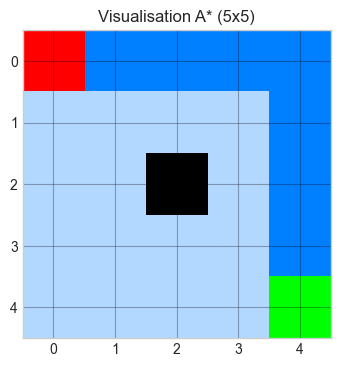

In [43]:
# définition d'une grille et recherche A*
grid = Grid(5, 5, obstacles=[(2, 2)])
start = (0, 0)
goal = (4, 4)

searcher = AStar(grid, heuristic='manhattan')
result = searcher.search(start, goal, algorithm='astar')

print("Chemin trouvé:", result['path'])
print("Coût:", result['cost'])
print("Noeuds explorés:", result['nodes_expanded'])

# Visualiser la grille et le chemin
viz = np.ones((grid.height, grid.width, 3))
for (x, y) in grid.obstacles:
    viz[y, x] = [0, 0, 0]
for node in result['visited']:
    x, y = node
    viz[y, x] = [0.7, 0.85, 1.0]
if result['success'] and result['path']:
    for node in result['path'][1:-1]:
        x, y = node
        viz[y, x] = [0, 0.5, 1.0]

viz[start[1], start[0]] = [1, 0, 0]
viz[goal[1], goal[0]] = [0, 1, 0]

plt.figure(figsize=(4, 4))
plt.imshow(viz, origin='upper', interpolation='none')
plt.grid(True, color='black', alpha=0.3)
plt.title("Visualisation A* (5x5)")
plt.show()


### Expériences et figures

Les fonctions `figure_1` à `figure_5` définies dans
`experiments.py` exécutent les expériences et génèrent des graphiques. Nous
les appelons ci‑dessous pour produire chaque figure et les visualiser inline.


In [44]:
# patch : ajouter heuristique euclidienne à toutes grilles (nécessaire pour AStar)
for Gclass in (Grid,):
    if not hasattr(Gclass, 'euclidean_distance'):
        def euclidean_distance(self, pos1, pos2):
            return float(np.sqrt((pos1[0]-pos2[0])**2 + (pos1[1]-pos2[1])**2))
        Gclass.euclidean_distance = euclidean_distance
# patch experiments.Grid as well (utilisée dans le module experiments)
import experiments
if not hasattr(experiments.Grid, 'euclidean_distance'):
    def euclidean_distance_ex(self, pos1, pos2):
        return float(np.sqrt((pos1[0]-pos2[0])**2 + (pos1[1]-pos2[1])**2))
    experiments.Grid.euclidean_distance = euclidean_distance_ex


#### Figure 1 : visualisation des chemins

Cette expérience calcule des chemins pour les trois algorithmes (UCS,
Greedy, A*) sur chacune des grilles de test et affiche une grille colorée
avec le parcours et les noeuds explorés.

  Facile     ucs      : Cout=8, Noeuds=23
  Facile     greedy   : Cout=8, Noeuds=8
  Facile     astar    : Cout=8, Noeuds=23
  Moyenne    ucs      : Cout=14, Noeuds=57
  Moyenne    greedy   : Cout=14, Noeuds=14
  Moyenne    astar    : Cout=14, Noeuds=55
  Difficile  ucs      : Cout=18, Noeuds=88
  Difficile  greedy   : Cout=18, Noeuds=18
  Difficile  astar    : Cout=18, Noeuds=84


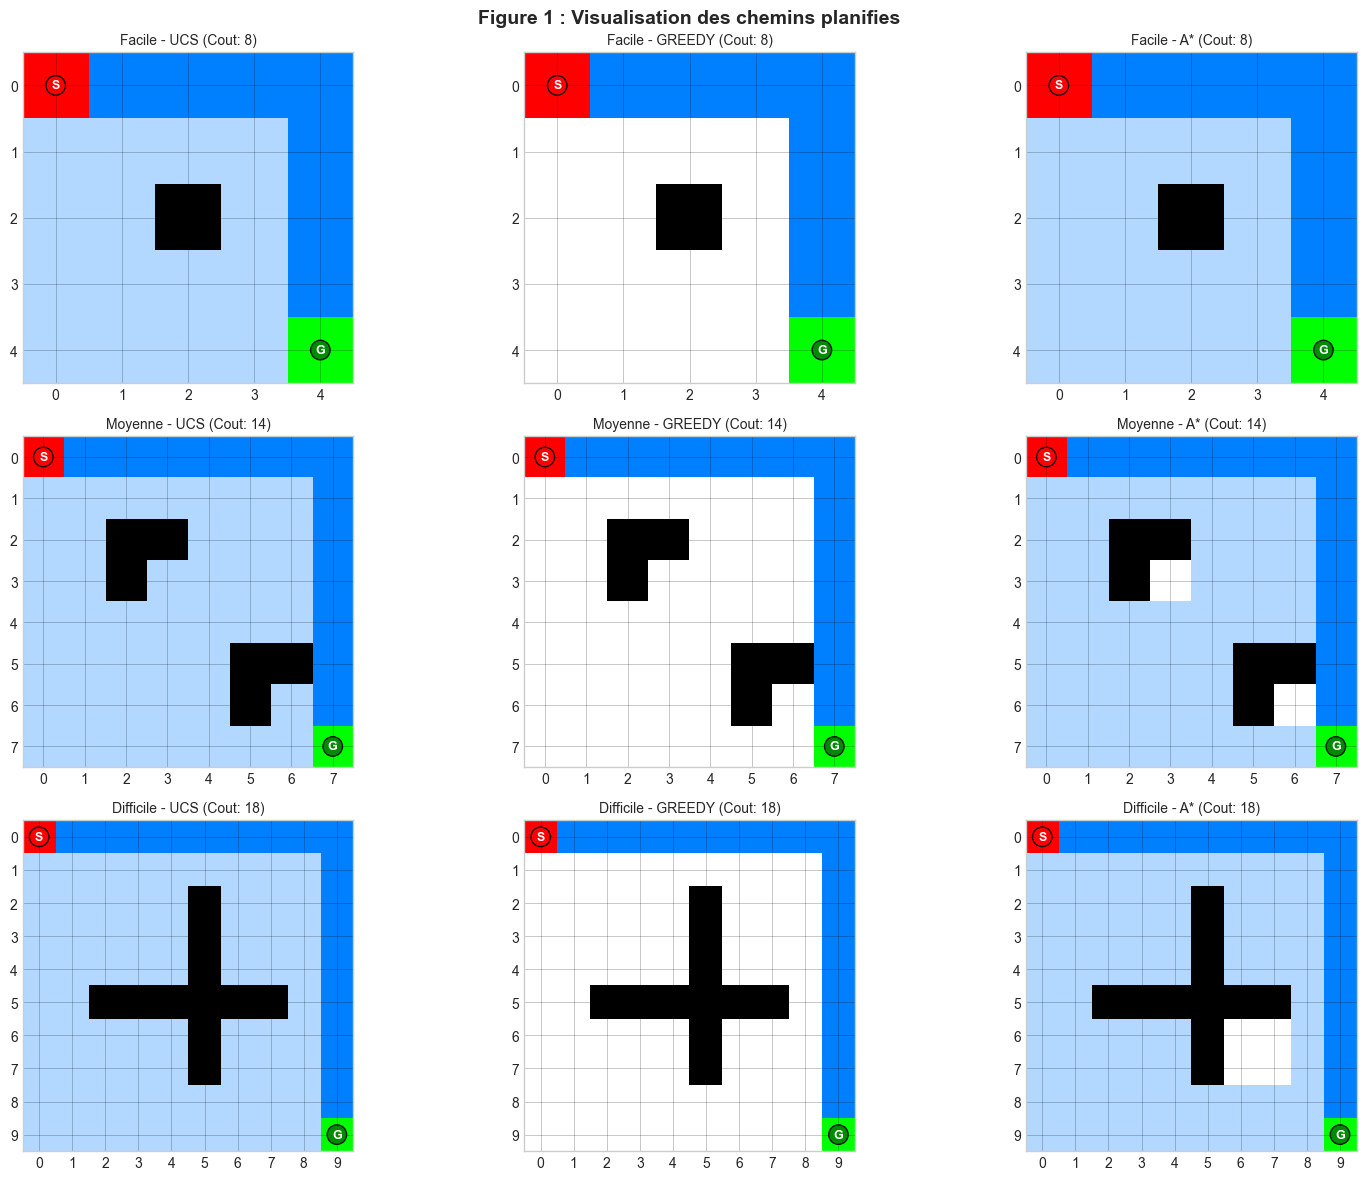

In [45]:
#### Figure 1 : visualisation des chemins
grids_config = get_test_grids()
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Figure 1 : Visualisation des chemins planifies",
             fontsize=14, fontweight='bold')

plot_idx = 1
for grid_config in grids_config:
    grid  = grid_config['grid']
    start = grid_config['start']
    goal  = grid_config['goal']
    searcher = AStar(grid, heuristic='manhattan')
    results  = {}

    for algo in ['ucs', 'greedy', 'astar']:
        result       = searcher.search(start, goal, algorithm=algo)
        results[algo] = result
        print(f"  {grid_config['name']:10} {algo:8} : "
              f"Cout={result['cost']}, Noeuds={result['nodes_expanded']}")

    for algo in ['ucs', 'greedy', 'astar']:
        ax     = plt.subplot(3, 3, plot_idx)
        result = results[algo]
        viz    = np.ones((grid.height, grid.width, 3))

        for y in range(grid.height):
            for x in range(grid.width):
                if not grid.is_free(x, y):
                    viz[y, x] = [0, 0, 0]

        for node in result['visited']:
            x, y = node
            viz[y, x] = [0.7, 0.85, 1.0]

        if result['success'] and result['path']:
            for node in result['path'][1:-1]:
                x, y = node
                viz[y, x] = [0.0, 0.5, 1.0]

        sx, sy = start
        gx, gy = goal
        viz[sy, sx] = [1, 0, 0]
        viz[gy, gx] = [0, 1, 0]

        ax.imshow(viz, origin='upper', aspect='equal',
                  interpolation='none')
        ax.grid(True, alpha=0.3, linewidth=0.5, color='black')
        ax.set_xticks(range(grid.width))
        ax.set_yticks(range(grid.height))

        ax.text(sx, sy, 'S', ha='center', va='center',
                fontweight='bold', fontsize=9, color='white',
                bbox=dict(boxstyle='circle', facecolor='red', alpha=0.9))
        ax.text(gx, gy, 'G', ha='center', va='center',
                fontweight='bold', fontsize=9, color='white',
                bbox=dict(boxstyle='circle', facecolor='green', alpha=0.9))

        algo_label = {'ucs': 'UCS', 'greedy': 'GREEDY', 'astar': 'A*'}[algo]
        ax.set_title(
            f"{grid_config['name']} - {algo_label} "
            f"(Cout: {result['cost']})",
            fontsize=10)
        plot_idx += 1

plt.tight_layout()
plt.show()

#### Figure 2 : comparaison des algorithmes

Cette cellule produit un graphique à barres montrant le coût et le nombre de
noeuds développés par UCS, Greedy et A* pour chaque grille de test.

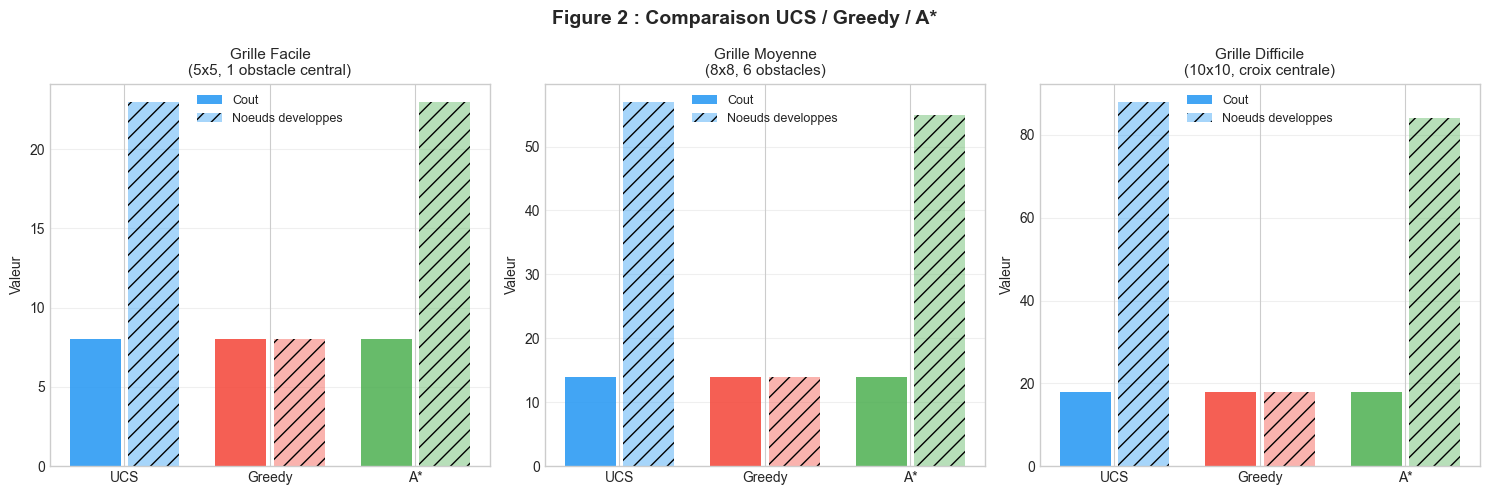

In [46]:
#### Figure 2 : comparaison des algorithmes
grids   = get_test_grids()
results = {}

for cfg in grids:
    searcher        = AStar(cfg['grid'], heuristic='manhattan')
    results[cfg['name']] = {}
    for algo in ['ucs', 'greedy', 'astar']:
        r = searcher.search(cfg['start'], cfg['goal'], algorithm=algo)
        results[cfg['name']][algo] = r

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 2 : Comparaison UCS / Greedy / A*",
             fontsize=14, fontweight='bold')

algos  = ['ucs', 'greedy', 'astar']
colors = ['#2196F3', '#F44336', '#4CAF50']
x      = np.arange(len(algos))

for ax, cfg in zip(axes, grids):
    res   = results[cfg['name']]
    costs = [res[a]['cost']           for a in algos]
    nodes = [res[a]['nodes_expanded'] for a in algos]

    ax.bar(x - 0.2, costs, 0.35, label='Cout',
           color=colors, alpha=0.85)
    ax.bar(x + 0.2, nodes, 0.35, label='Noeuds developpes',
           color=colors, alpha=0.4, hatch='//')

    ax.set_title(f"Grille {cfg['name']}\n({cfg['desc']})",
                 fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['UCS', 'Greedy', 'A*'])
    ax.set_ylabel("Valeur")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Figure 3 : impact de l'incertitude epsilon

On étudie comment la probabilité d'atteindre le but évolue, en comparant
des résultats théoriques (analyse d'absorption) et empiriques (simulations).

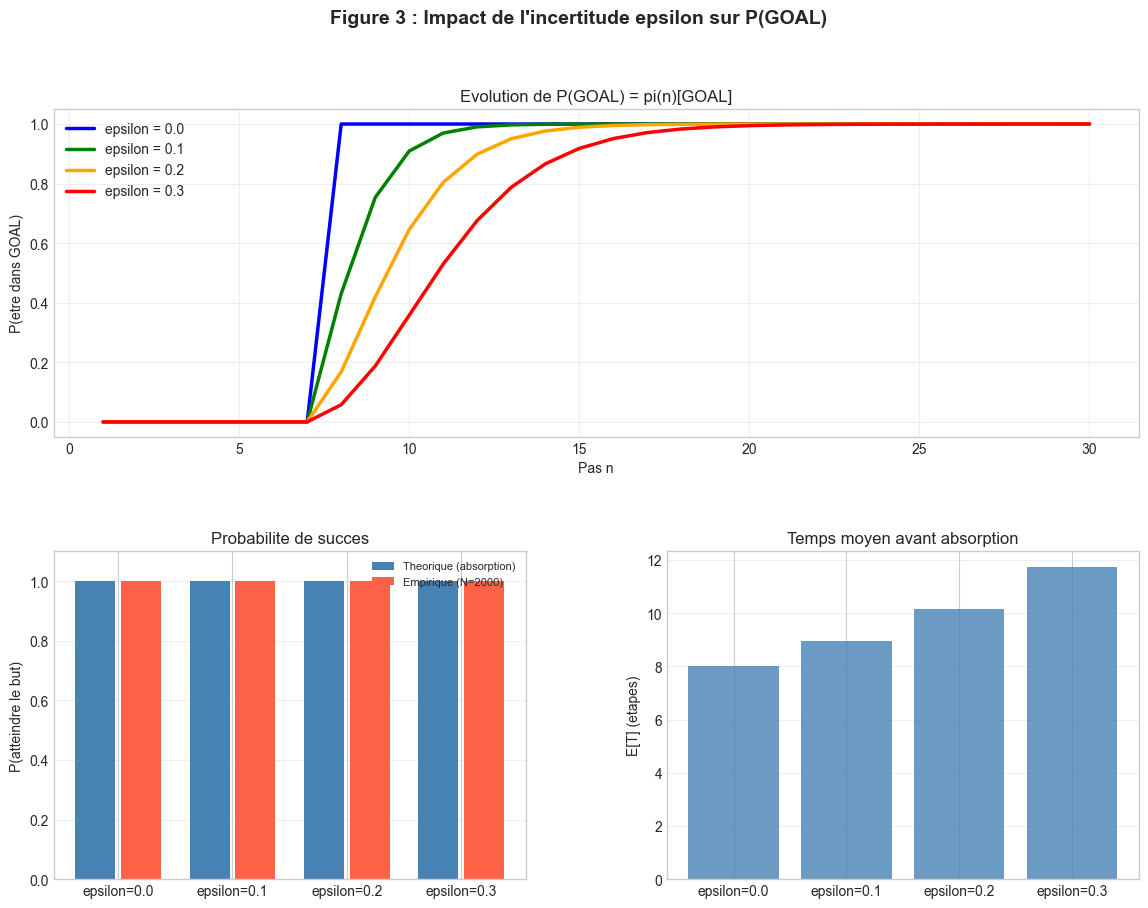

In [47]:
#### Figure 3 : impact de l'incertitude epsilon
cfg            = get_test_grids()[0]
grid, start, goal = cfg['grid'], cfg['start'], cfg['goal']
epsilons = [0.0, 0.1, 0.2, 0.3]
n_steps  = 30
N_SIM    = 2000

searcher = AStar(grid, heuristic='manhattan')
result   = searcher.search(start, goal, algorithm='astar')
policy   = searcher.extract_policy(result['path'])

results = []
for eps in epsilons:
    absorbing  = {goal: 'GOAL', (-1,-1): 'FAIL'}
    all_states = set(result['path']) | {(-1,-1)}
    mc = MarkovChain(all_states, absorbing)
    mc.build_from_policy(policy, grid, epsilon=eps)

    evol       = mc.get_distribution_evolution(start, n_steps)
    goal_idx   = mc.state_to_idx[goal]
    p_goal_evol = [d[goal_idx] for d in evol]

    ab          = mc.absorption_analysis()
    p_goal_abs  = 0
    t_abs       = 0
    if ab and start in mc.state_to_idx:
        i0 = mc.state_to_idx[start]
        if i0 in ab['trans_indices']:
            loc = ab['trans_indices'].index(i0)
            for j, ai in enumerate(ab['abs_indices']):
                if mc.idx_to_state[ai] == goal:
                    p_goal_abs = ab['B'][loc, j]
                    t_abs      = ab['t'][loc]
                    break

    sim        = MarkovSimulation(mc)
    stats      = sim.run_simulations(start,
                                     n_simulations=N_SIM,
                                     max_steps=100)
    p_goal_emp = stats['goal_count'] / N_SIM

    results.append({
        'epsilon':    eps,
        'evol':       p_goal_evol,
        'p_goal_abs': p_goal_abs,
        'p_goal_emp': p_goal_emp,
        't_abs':      t_abs,
    })

fig = plt.figure(figsize=(14, 10))
gs  = plt.matplotlib.gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1    = fig.add_subplot(gs[0, :])
colors = ['blue', 'green', 'orange', 'red']
for i, res in enumerate(results):
    ax1.plot(range(1, n_steps+1), res['evol'],
             color=colors[i], linewidth=2.5,
             label=f"epsilon = {res['epsilon']:.1f}")
ax1.set_xlabel("Pas n")
ax1.set_ylabel("P(etre dans GOAL)")
ax1.set_title("Evolution de P(GOAL) = pi(n)[GOAL]")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

ax2         = fig.add_subplot(gs[1, 0])
eps_labels  = [f"epsilon={r['epsilon']:.1f}" for r in results]
p_abs       = [r['p_goal_abs'] for r in results]
p_emp       = [r['p_goal_emp'] for r in results]
xi          = np.arange(len(results))
ax2.bar(xi - 0.2, p_abs, 0.35,
        label='Theorique (absorption)', color='steelblue')
ax2.bar(xi + 0.2, p_emp, 0.35,
        label=f'Empirique (N={N_SIM})', color='tomato')
ax2.set_xticks(xi)
ax2.set_xticklabels(eps_labels)
ax2.set_ylabel("P(atteindre le but)")
ax2.set_title("Probabilite de succes")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1.1])

ax3        = fig.add_subplot(gs[1, 1])
t_abs_vals = [r['t_abs'] for r in results]
ax3.bar(xi, t_abs_vals, color='steelblue', alpha=0.8)
ax3.set_xticks(xi)
ax3.set_xticklabels(eps_labels)
ax3.set_ylabel("E[T] (etapes)")
ax3.set_title("Temps moyen avant absorption")
ax3.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    "Figure 3 : Impact de l'incertitude epsilon sur P(GOAL)",
    fontsize=14, fontweight='bold')
plt.show()

#### Figure 4 : comparaison heuristiques

Comparaison du nombre de noeuds développés par A* avec heuristique nulle
(h = 0) versus Manhattan.

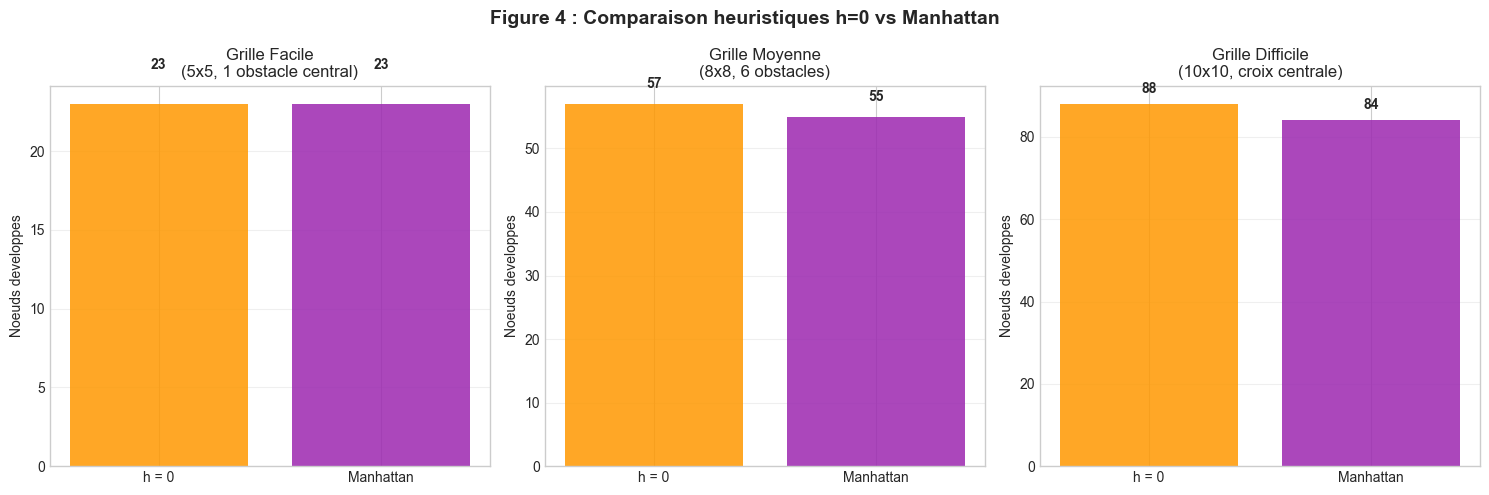

In [48]:
# #### Figure 4 : comparaison heuristiques
grids   = get_test_grids()
# garantir la présence de la méthode euclidean_distance sur les grilles
for cfg in grids:
    grid_obj = cfg['grid']
    if not hasattr(grid_obj, 'euclidean_distance'):
        grid_obj.euclidean_distance = lambda p1, p2: np.hypot(p1[0]-p2[0],
                                                               p1[1]-p2[1])

results = {}

for cfg in grids:
    results[cfg['name']] = {}
    for h_name in ['zero', 'manhattan']:
        searcher = AStar(cfg['grid'], heuristic=h_name)
        r = searcher.search(cfg['start'], cfg['goal'], algorithm='astar')
        results[cfg['name']][h_name] = r

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 4 : Comparaison heuristiques h=0 vs Manhattan",
             fontsize=14, fontweight='bold')

for ax, cfg in zip(axes, grids):
    res   = results[cfg['name']]
    nodes = [res['zero']['nodes_expanded'],
             res['manhattan']['nodes_expanded']]
    xi    = np.arange(2)
    bars  = ax.bar(xi, nodes,
                   color=['#FF9800', '#9C27B0'], alpha=0.85)

    for bar, val in zip(bars, nodes):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                str(val), ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_title(f"Grille {cfg['name']}\n({cfg['desc']})")
    ax.set_xticks(xi)
    ax.set_xticklabels(['h = 0', 'Manhattan'])
    ax.set_ylabel("Noeuds developpes")
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Figure 5 : Weighted A*

Étude du compromis vitesse/optimalité en variant le poids w de l'heuristique.

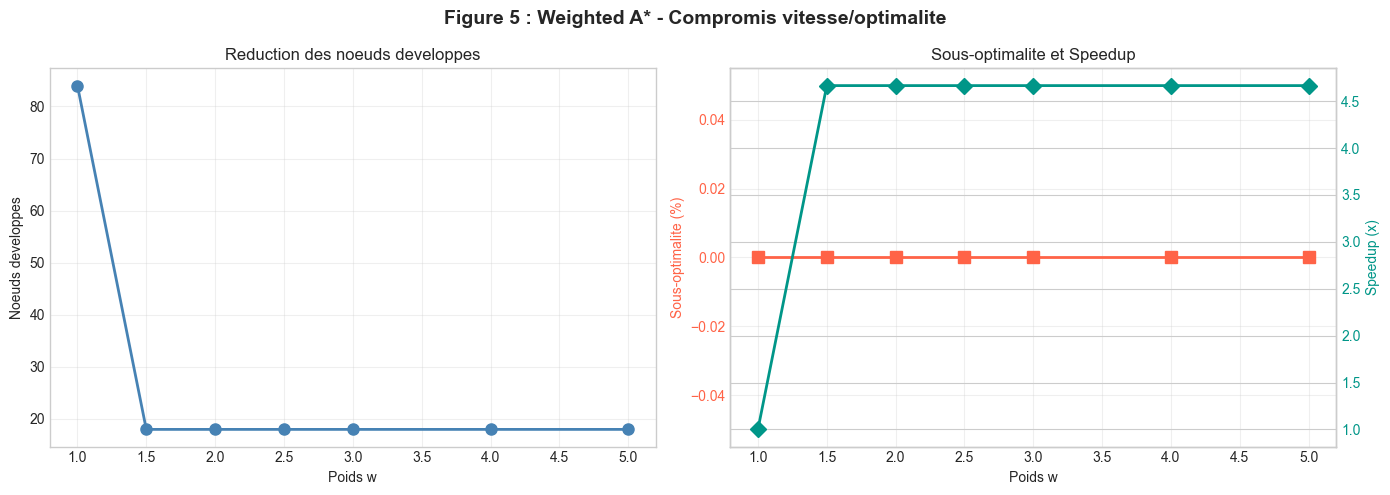

In [49]:
#### Figure 5 : Weighted A*
cfg             = get_test_grids()[2]
grid, start, goal = cfg['grid'], cfg['start'], cfg['goal']
weights = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

searcher = AStar(grid, heuristic='manhattan')
r_opt    = searcher.search(start, goal, algorithm='astar', weight=1.0)

results = []
for w in weights:
    r       = searcher.search(start, goal, algorithm='astar', weight=w)
    speedup = r_opt['nodes_expanded'] / max(r['nodes_expanded'], 1)
    results.append({'w': w, 'nodes': r['nodes_expanded'],
                    'speedup': speedup})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5 : Weighted A* - Compromis vitesse/optimalite",
             fontsize=14, fontweight='bold')

ws     = [r['w']       for r in results]
nodes  = [r['nodes']   for r in results]
speeds = [r['speedup'] for r in results]

ax1.plot(ws, nodes, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel("Poids w")
ax1.set_ylabel("Noeuds developpes")
ax1.set_title("Reduction des noeuds developpes")
ax1.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
ax2.plot(ws, [0]*len(ws), 's-', color='tomato',
         linewidth=2, markersize=8, label='Sous-optimalite (%)')
ax2_twin.plot(ws, speeds, 'D-', color='#009688',
              linewidth=2, markersize=8, label='Speedup (x)')

ax2.set_xlabel("Poids w")
ax2.set_ylabel("Sous-optimalite (%)", color='tomato')
ax2_twin.set_ylabel("Speedup (x)", color='#009688')
ax2.set_title("Sous-optimalite et Speedup")
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='y', labelcolor='tomato')
ax2_twin.tick_params(axis='y', labelcolor='#009688')

plt.tight_layout()
plt.show()

---

*Ce notebook montre comment reproduire toutes les figures de l'étude. Vous
pouvez modifier les paramètres des grilles et des simulations pour explorer
d'autres scénarios.*
